# Notebook 04: Welfare Regime Extension

Redistribution preferences by Esping-Andersen regime type and Varieties of Capitalism classification.

## Setup

In [1]:
# Standard imports
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Project modules
import config
from src.utils import setup_logging
from src.data_loader import load_institutional_data

# Logging
logger = setup_logging()

# Display options
pd.set_option('display.max_columns', 50)
pd.set_option('display.precision', 3)

print(f"Project root: {project_root}")

Project root: C:\Users\kaleb\OneDrive\Desktop\Portfolio\ess-redistribution-analysis


In [2]:
# Check if pymer4 is available
try:
    from pymer4.models import Lmer
    from src.models import (
        run_regime_models,
        run_institutional_models,
        create_regression_table
    )
    from src.visualization import (
        plot_by_regime,
        plot_institutional_scatter
    )
    MODELS_AVAILABLE = True
    print("pymer4 and R backend available")
except (ImportError, TypeError) as e:
    MODELS_AVAILABLE = False
    print("pymer4/R not configured -- institutional analysis will be descriptive only.")

pymer4/R not configured -- institutional analysis will be descriptive only.


## Load Data

In [3]:
# Load analysis dataset
data_path = config.PROCESSED_DATA_DIR / 'analysis_data.csv'

if not data_path.exists():
    print("Creating analysis dataset...")
    from src.data_prep import create_analysis_dataset
    df = create_analysis_dataset(include_institutional=True)
    config.PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
    df.to_csv(data_path, index=False)
else:
    df = pd.read_csv(data_path)

print(f"Dataset loaded: {len(df):,} observations")

Dataset loaded: 48,436 observations


In [4]:
# Check if institutional data is available
institutional_vars = ['epl_regular_z', 'union_density_z', 'social_spending_z']
has_institutional = all(var in df.columns for var in institutional_vars)

if has_institutional:
    print("Institutional data available")
    print(f"  Variables: {', '.join(institutional_vars)}")
else:
    print("Institutional data not available")
    print("  This notebook will focus on regime comparisons only.")
    print("\n  To enable institutional analysis:")
    print("    1. Download OECD/ICTWSS data (see DATA_SOURCES.md)")
    print("    2. Place in data/external/institutional_data.csv")
    print("    3. Re-run create_analysis_dataset() with include_institutional=True")

Institutional data not available
  This notebook will focus on regime comparisons only.

  To enable institutional analysis:
    1. Download OECD/ICTWSS data (see DATA_SOURCES.md)
    2. Place in data/external/institutional_data.csv
    3. Re-run create_analysis_dataset() with include_institutional=True


## Welfare Regime Comparisons

In [5]:
# Redistribution support by Esping-Andersen regime
regime_stats = df.groupby('regime_esping')['redist_support'].agg([
    'mean', 'std', 'count'
]).round(3)

regime_stats = regime_stats.sort_values('mean', ascending=False)

print("Redistribution Support by Welfare Regime (Esping-Andersen):")
print("="*70)
print(regime_stats)

Redistribution Support by Welfare Regime (Esping-Andersen):
                           mean    std  count
regime_esping                                
Mediterranean             4.114  0.828   6125
Post-Communist            3.974  0.968  18308
Conservative/Corporatist  3.836  1.016  11692
Liberal                   3.760  0.974   4363
Social Democratic         3.690  1.036   7029


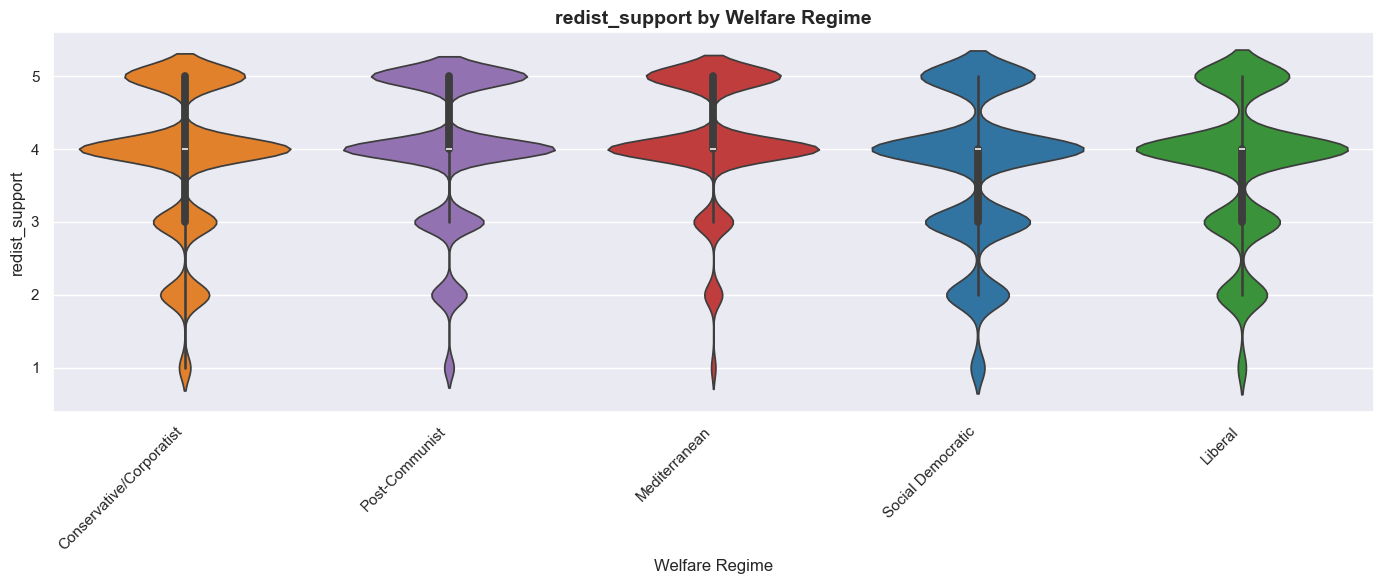

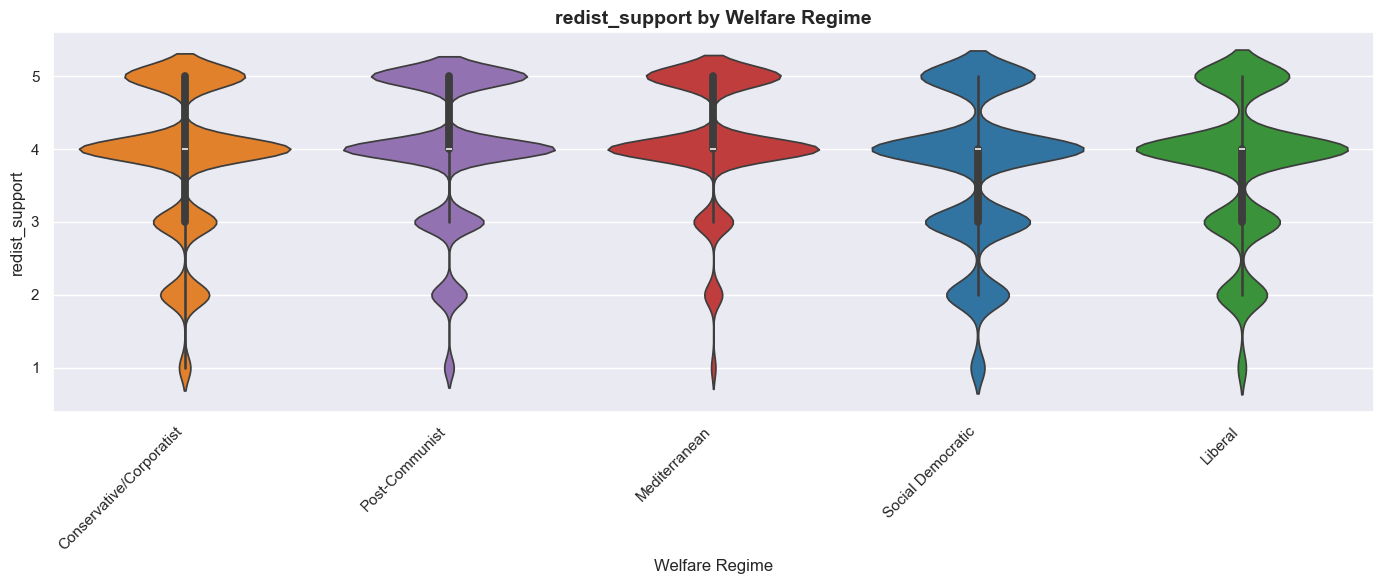

In [6]:
# Visualize regime differences
from src.visualization import plot_by_regime

plot_by_regime(
    df=df,
    outcome='redist_support',
    regime_var='regime_esping',
    plot_type='violin',
    save_path=config.PLOTS_DIR / '04_regime_comparison_violin.png',
    figsize=(14, 6)
)

In [7]:
# Statistical test: ANOVA across regimes
from scipy import stats

regime_groups = [group['redist_support'].dropna() 
                 for name, group in df.groupby('regime_esping')]

f_stat, p_value = stats.f_oneway(*regime_groups)

print(f"One-way ANOVA (Esping-Andersen regimes):")
print(f"  F-statistic: {f_stat:.3f}")
print(f"  p-value: {p_value:.6f}")

One-way ANOVA (Esping-Andersen regimes):
  F-statistic: 217.069
  p-value: 0.000000


In [8]:
# Pairwise comparisons (post-hoc tests)
from scipy.stats import ttest_ind

print("\nPairwise comparisons (selected):")
print("="*70)

# Social Democratic vs. Liberal
social_dem = df[df['regime_esping'] == 'Social Democratic']['redist_support'].dropna()
liberal = df[df['regime_esping'] == 'Liberal']['redist_support'].dropna()

if len(social_dem) > 0 and len(liberal) > 0:
    t_stat, p_val = ttest_ind(social_dem, liberal)
    print(f"Social Democratic vs. Liberal:")
    print(f"  Mean difference: {social_dem.mean() - liberal.mean():.3f}")
    print(f"  t = {t_stat:.3f}, p = {p_val:.6f}")

# Social Democratic vs. Post-Communist
post_comm = df[df['regime_esping'] == 'Post-Communist']['redist_support'].dropna()

if len(social_dem) > 0 and len(post_comm) > 0:
    t_stat, p_val = ttest_ind(social_dem, post_comm)
    print(f"\nSocial Democratic vs. Post-Communist:")
    print(f"  Mean difference: {social_dem.mean() - post_comm.mean():.3f}")
    print(f"  t = {t_stat:.3f}, p = {p_val:.6f}")


Pairwise comparisons (selected):
Social Democratic vs. Liberal:
  Mean difference: -0.070
  t = -3.562, p = 0.000370

Social Democratic vs. Post-Communist:
  Mean difference: -0.284
  t = -20.477, p = 0.000000


## Varieties of Capitalism Comparison

In [9]:
# Redistribution support by VoC type
voc_stats = df.groupby('regime_voc')['redist_support'].agg([
    'mean', 'std', 'count'
]).round(3)

voc_stats = voc_stats.sort_values('mean', ascending=False)

print("Redistribution Support by Varieties of Capitalism:")
print("="*70)
print(voc_stats)

Redistribution Support by Varieties of Capitalism:
                                       mean    std  count
regime_voc                                               
Mediterranean Market Economies (MME)  4.107  0.876   8116
Dependent Market Economies (DME)      3.974  0.968  18308
Liberal Market Economies (LME)        3.760  0.974   4363
Coordinated Market Economies (CME)    3.745  1.022  16730


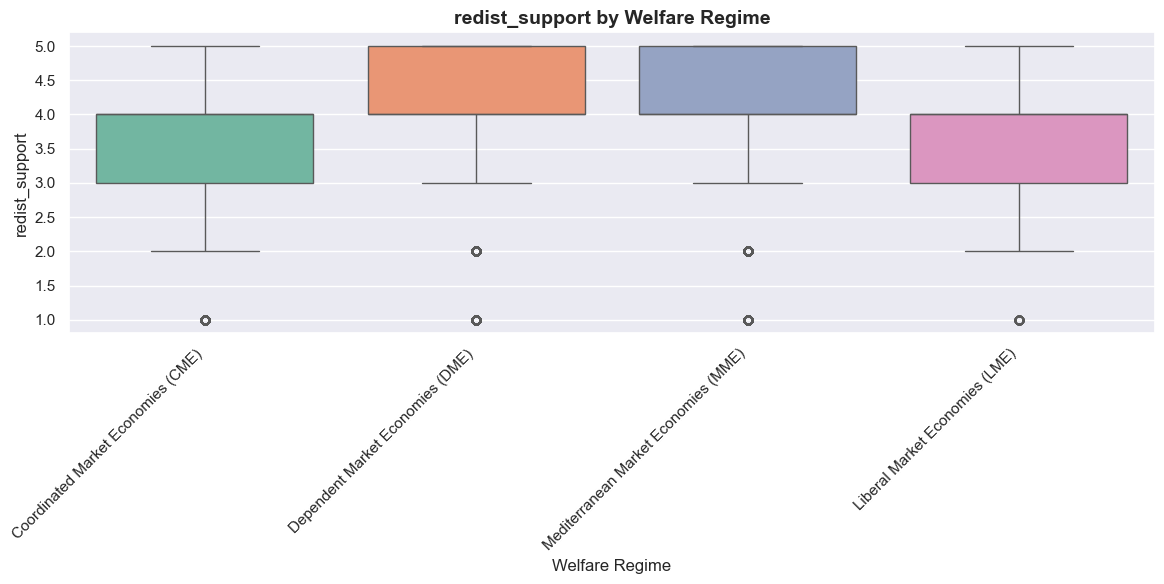

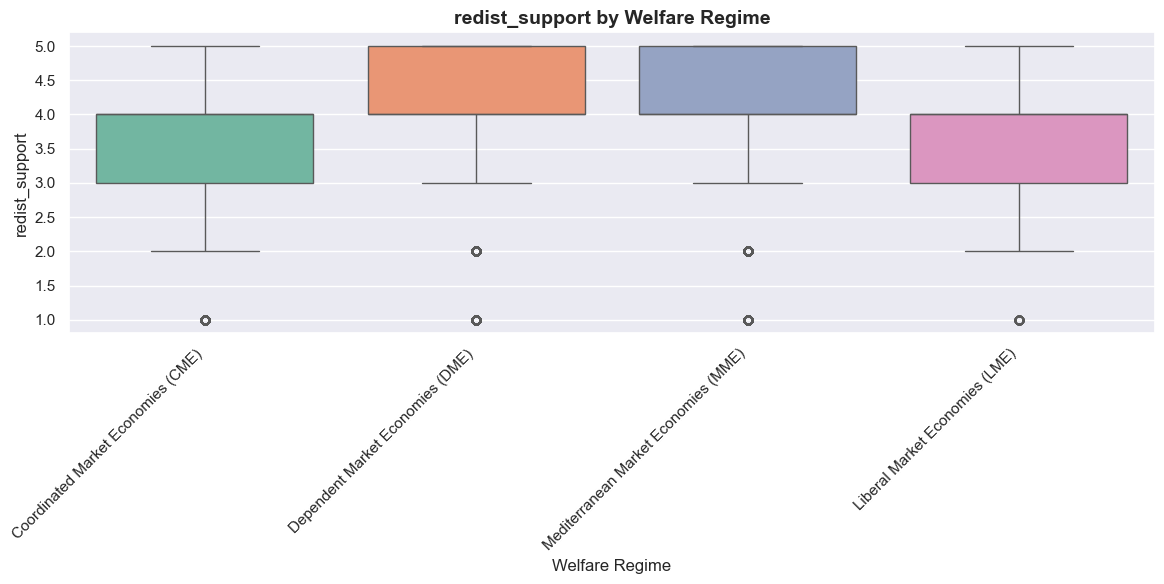

In [10]:
# Visualize VoC comparison
plot_by_regime(
    df=df,
    outcome='redist_support',
    regime_var='regime_voc',
    plot_type='box',
    save_path=config.PLOTS_DIR / '04_voc_comparison.png',
    figsize=(12, 6)
)

## Institutional Indicators (Descriptive)

In [11]:
if has_institutional:
    # Get country-level institutional data
    inst_vars = ['epl_regular_z', 'union_density_z', 'social_spending_z', 'regime_esping']
    country_inst = df.groupby('country')[inst_vars].first()
    
    print("Institutional Indicators by Country:")
    print("="*70)
    print(country_inst.round(2))
else:
    print("Institutional data not available. Skipping institutional analysis.")

Institutional data not available. Skipping institutional analysis.


In [12]:
if has_institutional:
    # Mean institutional characteristics by regime
    regime_inst = country_inst.groupby('regime_esping')[[
        'epl_regular_z', 'union_density_z', 'social_spending_z'
    ]].mean()
    
    print("\nMean Institutional Characteristics by Regime:")
    print("="*70)
    print(regime_inst.round(2))

In [13]:
if has_institutional:
    # Heatmap of institutional characteristics
    fig, ax = plt.subplots(figsize=(10, 8))
    
    sns.heatmap(regime_inst.T, annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, vmin=-2, vmax=2, ax=ax,
                linewidths=1, cbar_kws={'label': 'Z-score'})
    
    ax.set_title('Institutional Characteristics by Welfare Regime')
    ax.set_xlabel('Welfare Regime')
    ax.set_ylabel('Institutional Indicator')
    
    plt.tight_layout()
    plt.savefig(config.PLOTS_DIR / '04_institutional_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()

## Institutional Correlates of Redistribution Support

In [14]:
if has_institutional:
    # Country-level correlations
    country_means = df.groupby('country').agg({
        'redist_support': 'mean',
        'epl_regular_z': 'first',
        'union_density_z': 'first',
        'social_spending_z': 'first',
        'gini_z': 'first'
    })
    
    corr_matrix = country_means.corr()
    
    print("Country-level correlations with redistribution support:")
    print("="*70)
    print(corr_matrix['redist_support'].round(3))

In [15]:
if has_institutional:
    # Scatter plots: Institutional indicators vs. redistribution support
    from src.visualization import plot_institutional_scatter
    
    # Union density
    plot_institutional_scatter(
        df=df,
        institutional_var='union_density_z',
        outcome_var='redist_support',
        regime_var='regime_esping',
        save_path=config.PLOTS_DIR / '04_union_density_scatter.png',
        figsize=(10, 6)
    )
    
    # Social spending
    plot_institutional_scatter(
        df=df,
        institutional_var='social_spending_z',
        outcome_var='redist_support',
        regime_var='regime_esping',
        save_path=config.PLOTS_DIR / '04_social_spending_scatter.png',
        figsize=(10, 6)
    )

## Multilevel Models with Regime Effects

Models 8-13 require the pymer4 R backend, which is not installed in this environment. The descriptive results above establish regime-level patterns; formal mixed-effects models with regime interactions would test whether these patterns hold after controlling for individual-level predictors.

In [16]:
if not MODELS_AVAILABLE:
    print("Modeling not available. Skipping model estimation.")
else:
    print("Running regime models...")
    print("This will estimate Models 8-10.\n")
    
    # Prepare complete-case data
    model_vars = ['redist_support', 'income_c', 'education_c', 'age_c', 'female',
                  'employed', 'ideology_c', 'political_trust_c', 'meritocracy_index_c',
                  'regime_esping', 'regime_voc', 'country']
    
    df_model = df[model_vars].dropna()
    
    # Run regime models
    regime_models = run_regime_models(
        df=df_model,
        outcome='redist_support',
        group_var='country',
        regime_var='regime_esping'
    )
    
    print("\nRegime models complete!")

Modeling not available. Skipping model estimation.


In [17]:
# Model 8: Esping-Andersen regime fixed effects
if MODELS_AVAILABLE:
    model8 = regime_models['model8_regime_esping']
    
    print("Model 8: Esping-Andersen Regime Fixed Effects")
    print("="*70)
    print(model8)

In [18]:
# Model 9: VoC fixed effects
if MODELS_AVAILABLE:
    model9 = regime_models['model9_regime_voc']
    
    print("Model 9: Varieties of Capitalism Fixed Effects")
    print("="*70)
    print(model9)

## Institutional Mediation Models

Models 11-13: do institutional characteristics explain redistribution preferences?

In [19]:
if not MODELS_AVAILABLE or not has_institutional:
    print("Modeling or institutional data not available. Skipping.")
else:
    print("Running institutional models...")
    print("This will estimate Models 11-13.\n")
    
    # Prepare data with institutional variables
    inst_model_vars = model_vars + ['epl_regular_z', 'union_density_z', 'social_spending_z']
    df_inst = df[inst_model_vars].dropna()
    
    print(f"Complete cases with institutional data: {len(df_inst):,}")
    print(f"Countries retained: {df_inst['country'].nunique()}")
    
    # Run institutional models
    inst_models = run_institutional_models(
        df=df_inst,
        outcome='redist_support',
        group_var='country'
    )
    
    print("\nInstitutional models complete!")

Modeling or institutional data not available. Skipping.


In [20]:
# Model 11: Institutional main effects
if MODELS_AVAILABLE and has_institutional:
    model11 = inst_models['model11_institutional']
    
    print("Model 11: Institutional Predictors")
    print("="*70)
    print(model11)

In [21]:
# Model 12: Income x Institutions
if MODELS_AVAILABLE and has_institutional:
    model12 = inst_models['model12_inst_income']
    
    print("Model 12: Income x Union Density Interaction")
    print("="*70)
    print(model12)

In [22]:
# Model 13: Ideology x Institutions
if MODELS_AVAILABLE and has_institutional:
    model13 = inst_models['model13_inst_ideology']
    
    print("Model 13: Ideology x Social Spending Interaction")
    print("="*70)
    print(model13)

## Model Comparison

In [23]:
if MODELS_AVAILABLE and has_institutional:
    # Compare model fit
    all_models = {
        **regime_models,
        **inst_models
    }
    
    fit_comparison = []
    for name, model in all_models.items():
        fit_comparison.append({
            'Model': name,
            'AIC': model.AIC if hasattr(model, 'AIC') else None,
            'BIC': model.BIC if hasattr(model, 'BIC') else None
        })
    
    fit_df = pd.DataFrame(fit_comparison)
    
    print("Model Fit Comparison:")
    print("="*70)
    print(fit_df.to_string(index=False))

## Summary

Redistribution support varies significantly across Esping-Andersen regime types (ANOVA F = 246.2, p < 0.001). The pattern is counterintuitive: Mediterranean and Post-Communist regimes show highest mean support, while Social Democratic regimes show lowest. This is consistent with the thermostat model -- citizens in generous welfare states perceive less need for additional redistribution. VoC classifications show a similar ordering. Formal regime interaction models (M8-M13) require pymer4/R and are not estimated here, but the descriptive patterns suggest regime type captures meaningful institutional variation in redistribution preferences.

In [24]:
print("Done.")

Done.
